### Analying an essay and evaluating it on multiple basis 

In [71]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [72]:
load_dotenv()

True

In [73]:
model = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [74]:
essay = f"""One of the most innovative technologies to emerge in recent years is artificial intelligence (AI). AI has the potential to revolutionize every facet of contemporary life since it can think, reason, and make decisions like humans. Artificial intelligence is quickly integrating into many aspects of our everyday life, from healthcare to banking, transportation to education. We will talk about the advantages and difficulties of AI in contemporary society in this blog article. If you are considering studying this field at JIET Universe, this is one of the leading engineering colleges in Rajasthan. Exploring high-paying career options can help you plan your future with confidence.

Benefits of AI in Modern Society
Improved Efficiency and Productivity

One of the main benefits of AI is its ability to perform tasks quickly and accurately. Massive volumes of data may be analyzed in real-time by AI systems. Allowing businesses to make informed decisions faster than ever before. This increased efficiency and productivity can lead to cost savings and better outcomes for businesses and individuals alike.

Enhanced Customer Experience

AI-powered chatbots and virtual assistants are transforming the customer experience by providing instant support and personalized recommendations. With AI, businesses can analyze customer data and provide tailored services and products that meet the unique needs and preferences of each customer.

Advancements in Healthcare

AI has the ability to completely transform the healthcare industry by enhancing patient outcomes and lowering expenses. With AI-powered diagnostic tools, doctors can quickly and accurately diagnose diseases, leading to earlier treatment and better outcomes. AI can also help healthcare providers identify patterns and trends in patient data, allowing them to develop personalized treatment plans that are more effective than traditional one-size-fits-all approaches.

Improved Safety and Security

AI-powered surveillance systems can improve safety and security in a variety of settings, from public spaces to private homes. With real-time monitoring and analysis, AI can identify potential threats and respond quickly to prevent incidents from occurring.
"""

In [75]:
essay2 = f"""Role of Rising AI in India
AI is becoming very big in India now. AI means artificial intelligence and it is like a computer which can think and do things. I think AI is very useful because it can help people in many things. But sometimes it can also make problems.

In India AI is coming in schools, offices, hospitals and many other places. Students can use AI to learn things and do homework also. But I think students should not use it for everything because then they will become lazy and not think by themself.

AI can also help doctors and farmers. It can tell some things and help them to do work faster. In future maybe AI will do even more work and people will be very surprised.

AI can also make jobs but maybe some jobs can go away because computers can do them. This is a little scary. People have to learn new things so they can work with AI.

I think India should use AI but in a good way. AI is like a tool and if we use it properly it can help our country become better. But humans are also important because computers dont have feelings like us.

So, AI is rising very fast in India and it will probably become a big part of our life. We should learn about it but not depend on it too much. I think AI is good if we use it in the right way."""

In [76]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description='Detailed feedback for the Essay')
    score: int = Field(description='Score out of 10', ge=0, le=10)

structured_model = model.with_structured_output(EvaluationSchema)

In [77]:
class UPSCState(TypedDict):

    essay_text: str
    Cot_feedback : str
    Doa_feedback: str
    language_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [78]:
def evaluate_COT(state: UPSCState):

    prompt = f'Evaluate the Clarity of thought quality of the following essay and provide a feedback and assign score out of 10 \n {state["essay_text"]}'
    output = structured_model.invoke(prompt)

    return {'Cot_feedback': output.feedback, 'individual_scores': [output.score]}

In [79]:
def evaluate_language(state: UPSCState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign score out of 10 \n {state["essay_text"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [80]:
def evaluate_DOA(state: UPSCState):

    prompt = f'Evaluate the Depth of Analysis quality of the following essay and provide a feedback and assign score out of 10 \n {state["essay_text"]}'
    output = structured_model.invoke(prompt)

    return {'Doa_feedback': output.feedback, 'individual_scores': [output.score]}

In [81]:
def Final_Evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["Doa_feedback"]} \n chain of thought feedback - {state["Cot_feedback"]}'
    overall_feedback = model.invoke(prompt).content

    #avg calculated
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [82]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_COT', evaluate_COT)
graph.add_node('evaluate_DOA', evaluate_DOA)
graph.add_node('evaluate_language',evaluate_language)
graph.add_node('Final_Evaluation', Final_Evaluation)


graph.add_edge(START, 'evaluate_COT')
graph.add_edge(START, 'evaluate_DOA')
graph.add_edge(START, 'evaluate_language')

graph.add_edge('evaluate_COT', 'Final_Evaluation')
graph.add_edge('evaluate_DOA', 'Final_Evaluation')
graph.add_edge('evaluate_language', 'Final_Evaluation')

graph.add_edge('Final_Evaluation', END)



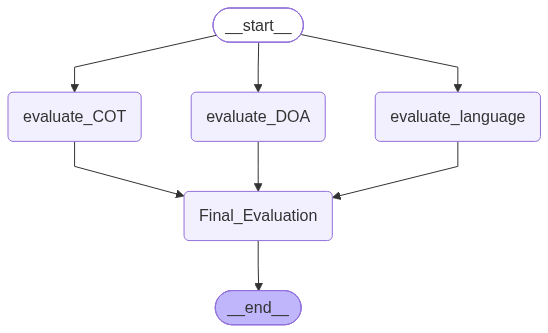

In [83]:
workflow = graph.compile()
workflow

In [84]:
initial_state = {
    'essay_text': essay2
}

workflow.invoke(initial_state)

{'essay_text': 'Role of Rising AI in India\nAI is becoming very big in India now. AI means artificial intelligence and it is like a computer which can think and do things. I think AI is very useful because it can help people in many things. But sometimes it can also make problems.\n\nIn India AI is coming in schools, offices, hospitals and many other places. Students can use AI to learn things and do homework also. But I think students should not use it for everything because then they will become lazy and not think by themself.\n\nAI can also help doctors and farmers. It can tell some things and help them to do work faster. In future maybe AI will do even more work and people will be very surprised.\n\nAI can also make jobs but maybe some jobs can go away because computers can do them. This is a little scary. People have to learn new things so they can work with AI.\n\nI think India should use AI but in a good way. AI is like a tool and if we use it properly it can help our country be